In [ ]:
# 한글깨짐 방지용

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

**1. 데이터 및 결과 수집**
- 행(5명): 직원 A, B, C, D, E
- 열(5개): [나이, 근속연수, 기본급, 성과급, 총급여]

In [10]:
import numpy as np
import pandas as pd

columns = ['나이', '근속년수', '기본급', '성과급', '총급여']
X_raw = np.array([
    [25,  2, 300,  50,  350],  # 직원 A
    [30,  7, 450,  60,  510],  # 직원 B
    [35, 12, 600,  80,  680],  # 직원 C
    [40, 17, 750, 100,  850],  # 직원 D
    [45, 22, 900, 120, 1020]   # 직원 E
], dtype=float)

# 실제 결과 y: 각 직원의 최종 연봉 (단위: 만 원)
y = np.array([3900, 5600, 7400, 9200, 11000])

df_raw = pd.DataFrame(X_raw, columns=columns)

print("=== 1단계: 수집된 5x5 행렬 ===")
print(f"행렬 크기 (Shape): {X_raw.shape}")

=== 1단계: 수집된 5x5 행렬 ===
행렬 크기 (Shape): (5, 5)


**1-1. 데이터 간 상관관계 분석**

- 1.00으로 파랗게 칠해진 변수들은 완벽히 중복된 '일차종속' 축 ---> rank로 확인

Text(0.5, 1.0, '1. 상관관계 (일차종속 진단)')

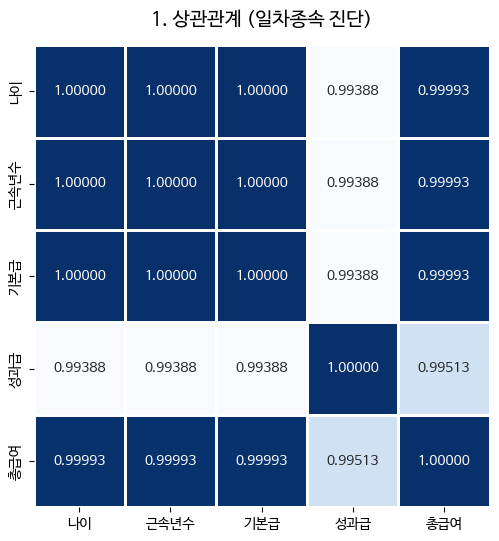

In [11]:
fig = plt.figure(figsize=(20, 6))
ax1 = fig.add_subplot(1, 3, 1)

# ==========================================================
# [그래프 1] 변수 간 상관관계 히트맵
# ==========================================================

# 상관관계 계산
corr_matrix = df_raw.corr()

# 히트맵 그리기
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".5f", linewidths=1, ax=ax1, cbar=False)
ax1.set_title("1. 상관관계 (일차종속 진단)", fontsize=14, pad=15)

**2. Rank 검사 및 데이터 다듬기 (차원 축소)**
- 5개 축(차원) 중에서 진짜 독립적인 축이 몇 개인지 검사
- 위 상관관계 그래프를 확인(나이, 근속년수, 기본급)

In [12]:
raw_rank = np.linalg.matrix_rank(X_raw)

print("=== 2단계: Rank 검사 결과 ===")
print(f"현재 행렬의 Rank: {raw_rank}")

# [진단] 5x5 행렬 ---> Rank는 3
# 진짜 독립적인 축(좌표)은 3, 나머지 2개는 껍데기 축이라는 뜻.
if raw_rank < X_raw.shape[1]:
    print(f"경고: {X_raw.shape[1] - raw_rank}개의 중복(일차종속) 축 발견! 불필요한 차원을 지웁니다.")

    # 중복된 1번째 열(근속연수)과 2번째 열(기본급)을 삭제
    # 위 상관관계 그래프를 확인
    # 지우고 나면 [나이, 성과급, 총급여] 3개의 핵심 축만 남게 됨.
    X_clean = np.delete(X_raw, [1, 2], axis=1)

    print(f"→ 전처리 후 행렬 크기: {X_clean.shape}")
    print(f"→ 전처리 후 행렬 Rank: {np.linalg.matrix_rank(X_clean)} (3차원 완성)")

=== 2단계: Rank 검사 결과 ===
현재 행렬의 Rank: 3
경고: 2개의 중복(일차종속) 축 발견! 불필요한 차원을 지웁니다.
→ 전처리 후 행렬 크기: (5, 3)
→ 전처리 후 행렬 Rank: 3 (3차원 완성)


**3. 역행렬 기반 가중치 계산**
- [Age, Bonus, Total] 3차원 축을 기반으로 가중치를 계산

In [13]:
print("=== 3단계: 역행렬로 가중치 계산 ===")

Xt_X = np.dot(X_clean.T, X_clean)
Xt_X_inv = np.linalg.inv(Xt_X)  # [나이, 성과급, 총급여]조합으로 완성된 안전한 역행렬
Xt_y = np.dot(X_clean.T, y)

# 최종 가중치 w 구하기
w = np.dot(Xt_X_inv, Xt_y)

print(f"계산된 진짜 독립 축들의 가중치(w): {w}")
# X_clean의 열 순서([나이, 성과급, 총급여])에 맞춰 해석을 매핑.
print(f"→ 해석: 나이 1살당 {w[0]:.1f}만 원, 성과급 1만 원당 {w[1]:.1f}만 원, 총급여 1만 원당 {w[2]:.1f}만 원이 연봉에 반영됨.")

=== 3단계: 역행렬로 가중치 계산 ===
계산된 진짜 독립 축들의 가중치(w): [13.33333333 -0.22222222 10.22222222]
→ 해석: 나이 1살당 13.3만 원, 성과급 1만 원당 -0.2만 원, 총급여 1만 원당 10.2만 원이 연봉에 반영됨.


**4. 모델 평가 및 신입사원 연봉 예측**
- [Age, Bonus, Total] 3차원 축을 기반으로 가중치를 계산

In [14]:
print("=== 4단계: 신입사원 연봉 예측 ===")

# 수집 양식은 [나이, 근속연수, 기본급, 성과급, 총급여]였지만,
# 가중치를 곱할 때는 핵심 축 [나이, 성과급, 총급여] 순서로 넣어준다.
# 예: 28세 신입사원 [나이: 28, 성과급: 30, 총급여: 350]
new_employee_clean = np.array([28, 30, 350])

# 예측 연봉 = 가중치(w)와 새로운 데이터의 내적(Dot)
predicted_salary = np.dot(new_employee_clean, w)
print(f"👤 28세 신입사원의 적정 연봉 예측치: {predicted_salary:.0f}만 원")

=== 4단계: 신입사원 연봉 예측 ===
👤 28세 신입사원의 적정 연봉 예측치: 3944만 원


**4-1. 2차원 연봉 예측선 계산**

- 축이 3개지만 2차원으로 그리기 위해 나이(35세), 성과급(30만 원)은 평균값으로 고정
- 역행렬로 구한 가중치(w)를 곱해 총급여 변화에 따른 연봉 예측선을 그림.
- (w[0]: 나이 가중치, w[1]: 성과급 가중치, w[2]: 총급여 가중치)

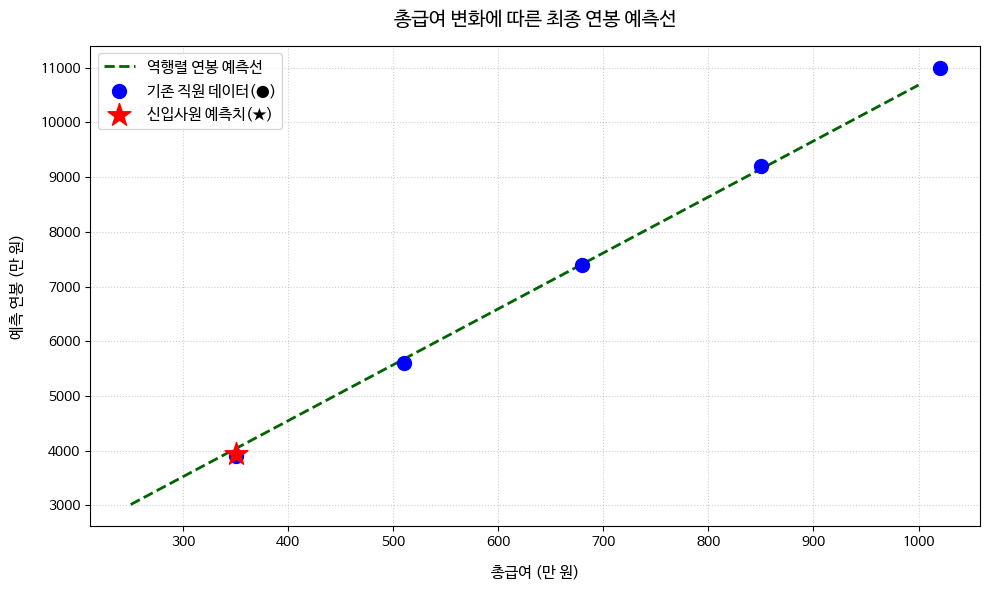

In [15]:
plt.close('all')
plt.figure(figsize=(10, 6))

# X축이 될 총급여의 범위(250만 원 ~ 600만 원)
total_line = np.linspace(250, 1000, 100)

# 나중엔 평균도 전체 데이터의 mean 함수를 통해 얻어보는 것을 추천
Age_fixed = 35
Bonus_fixed = 30
predicted_line = (Age_fixed * w[0]) + (Bonus_fixed * w[1]) + (total_line * w[2])

# 1) 역행렬 가중치가 만든 2차원 예측선 그리기
plt.plot(total_line, predicted_line, color='darkgreen', linestyle='--', linewidth=2, label='역행렬 연봉 예측선')

# 2) 실제 직원 5명의 데이터 점(●) 찍기 (X축: 총급여, Y축: 실제연봉)
# X_clean[:, 2]는 전처리 후 남아있는 '총급여' 열.
plt.scatter(X_clean[:, 2], y, color='blue', s=100, zorder=5, label='기존 직원 데이터(●)')

# 3) 4단계 신입사원 데이터(★) 예측치 점 찍기 (X축: 총급여 350, Y축: 예측연봉)
plt.scatter(new_employee_clean[2], predicted_salary, color='red', marker='*', s=300, zorder=6, label='신입사원 예측치(★)')

# ─── 그래프 스타일 및 레이블 세팅 ───
plt.title("총급여 변화에 따른 최종 연봉 예측선", fontsize=14, pad=15)
plt.xlabel("총급여 (만 원)", fontsize=11, labelpad=10)
plt.ylabel("예측 연봉 (만 원)", fontsize=11, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()